# Figure 2 · A few spectra reconstruct the whole mode map (stiff probe)

Production notebook for main-text Fig. 2. Ground truth: the stiff probe's dense map (run R2,
161 positions at 1 µm, 500 nN, 192 min), lever frame x − x₀ with x₀ = 28.1 µm. Every arm sees only
the N equispaced positions it is given and is scored on all the others (held-out complex NRMSE).

Arms:
- **EB**: single-band Euler–Bernoulli physics fit (`physrec`, setback fitted, stiff-probe preset);
- **EB+GP**: EB mean plus a GP on the residual;
- **GP**: model-free GP over position (length scale by PRESS);
- **low-rank**: rank-min(N, 6) Chebyshev fit (`activemodemap.lowrank`).

Learning curves per CR band come from `tools/run_2s.py` (cached in `results/_cache_02s.json`,
same protocol as the soft-probe notebook 02a). The earlier stiff lever (Grid B benchmark of the
draft) is in the SI.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
import json
from fmmpaper import physrec
C = json.loads((F.config.RESULTS_DIR / "_cache_02s.json").read_text())
X0 = C["_x0"]; TRUTH = C["_truth"]
s = F.load("scmpitB_r2_dense"); x = s.x_um - X0; f = s.freq_Hz; Z = s.Z[0]
BANDS = ["CR1", "CR2", "CR3"]; ARMS = ["EB", "EB+GP", "GP", "low-rank"]
lc = pd.DataFrame([dict(mode=k.split("|")[0], N=int(k.split("|")[1]), arm=a, nrmse=v[a]["nrmse"], node=v[a]["node_err_um"])
                   for k, v in C.items() if "|" in k for a in ARMS if a in v])
print("nodes (lever frame):", TRUTH)
lc.pivot_table(index=["mode", "N"], columns="arm", values="nrmse").round(3)

nodes (lever frame): {'CR1': [], 'CR2': [124.9], 'CR3': [88.9, 156.9]}


arm         EB  EB+GP     GP  low-rank
mode N                                
CR1  3   0.167  0.154  0.406     0.149
     4   0.160  0.135  0.352     0.116
     5   0.159  0.119  0.094     0.097
     6   0.158  0.114  0.094     0.093
     8   0.161  0.118  0.105     0.093
     10  0.159  0.103  0.088     0.071
     14  0.156  0.079  0.066     0.072
     20  0.157  0.075  0.065     0.071
     30  0.158  0.069  0.058     0.064
CR2  3   0.173  0.165  0.585     0.597
     4   0.151  0.136  0.206     0.170
     5   0.145  0.120  0.177     0.177
     6   0.141  0.118  0.120     0.130
     8   0.142  0.114  0.116     0.120
     10  0.140  0.105  0.121     0.135
     14  0.140  0.104  0.096     0.108
     20  0.141  0.102  0.111     0.109
     30  0.148  0.111  0.105     0.113
CR3  3   0.287  0.216  0.966     0.780
     4   0.341  0.316  0.948     0.580
     5   0.283  0.205  0.247     0.272
     6   0.327  0.231  0.186     0.208
     8   0.314  0.221  0.177     0.197
     10  0.286  0.193  0.174     0.194
     14  0.278  0.169  0.150     0.180
     20  0.279  0.164  0.154     0.181
     30  0.286  0.169  0.149     0.181

In [3]:
NMAP = 4
sel = recon.select_equispaced(x, NMAP); h = recon.held_out(len(x), sel)
full = {"GP": recon.rec_gp(x, sel, Z[sel])["Zrec"], "low-rank": recon.rec_lowrank(x, sel, Z[sel], rank=NMAP)["Zrec"]}
full_err = {k: recon.nrmse(v[h], Z[h]) for k, v in full.items()}
zb, fb = physrec.band_slice(f, Z, s.probe.bands_Hz["CR3"], n_max=250)
eb3 = physrec.rec_eb(x, sel, zb[sel], fb, physrec.GEOM["scmpitB"])
band3 = {"dense": zb, "EB+GP": eb3["Zrec"], "GP": recon.rec_gp(x, sel, zb[sel])["Zrec"],
         "low-rank": recon.rec_lowrank(x, sel, zb[sel], rank=NMAP)["Zrec"]}
print({k: round(v, 1) for k, v in full_err.items()}, "% full band at N =", NMAP)

{'GP': 31.6, 'low-rank': 35.4} % full band at N = 4


## The figure

[PosixPath('/home/claude/work/paper_analysis/figures/Fig2_sparse_reconstruction.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/Fig2_sparse_reconstruction.pdf')]

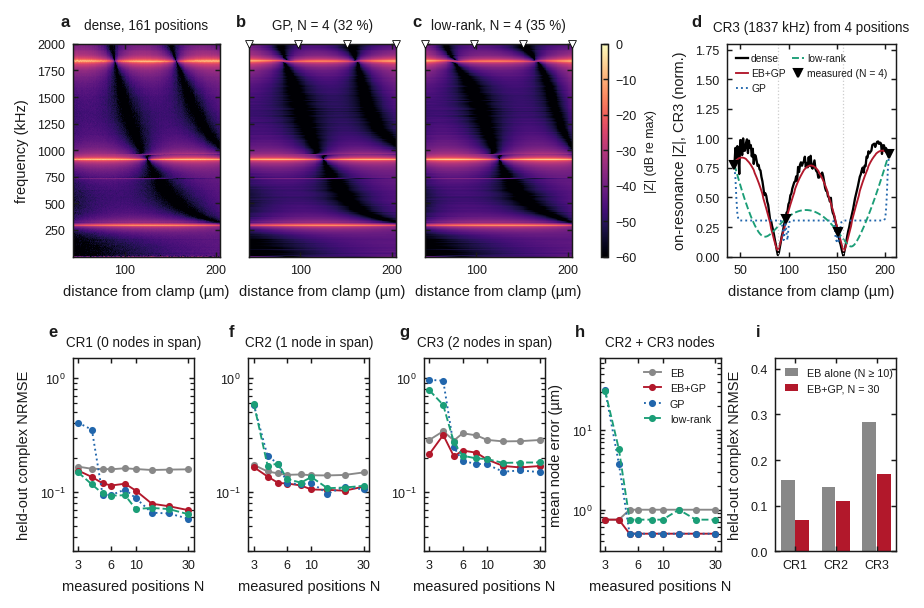

In [4]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(fp.WIDTH_IN["double"], fp.WIDTH_IN["double"] * 0.62))
gs = GridSpec(2, 1, figure=fig, height_ratios=[1.1, 1], hspace=0.5)
g1 = gs[0].subgridspec(1, 6, width_ratios=[1, 1, 1, 0.05, 0.42, 1.15], wspace=0.25)
g2 = gs[1].subgridspec(1, 5, wspace=0.45)
ref = np.abs(Z).max()
for i, (title, ZZ) in enumerate((("dense, 161 positions", Z), (f"GP, N = {NMAP} ({full_err['GP']:.0f} %)", full["GP"]),
                                 (f"low-rank, N = {NMAP} ({full_err['low-rank']:.0f} %)", full["low-rank"]))):
    ax = fig.add_subplot(g1[0, i])
    im = fp.map_db(ax, x, f, ZZ, ref=ref, fmax=2000, colorbar=False)
    if i:
        fp.mark_positions(ax, x[sel]); ax.set_ylabel(""); ax.set_yticklabels([])
    ax.set_title(title, fontsize=6.5, pad=7); ax.set_xlabel("distance from clamp (µm)")
    fp.panel_label(ax, "abc"[i], dy=1.07)
cb = fig.colorbar(im, cax=fig.add_subplot(g1[0, 3])); cb.set_label("|Z| (dB re max)", fontsize=6)
# d  CR3 band: on-resonance profile of every arm at N = 4
axd = fig.add_subplot(g1[0, 5])
k3 = int(np.argmax(np.abs(zb).mean(0)))
for k, (c, ls, lw) in {"dense": ("k", "-", 1.1), "EB+GP": (fp.C["ebgp"], "-", 0.9), "GP": (fp.C["gp"], ":", 0.9),
                       "low-rank": (fp.C["lowrank"], "--", 0.9)}.items():
    axd.plot(x, np.abs(band3[k][:, k3]) / np.abs(zb[:, k3]).max(), ls, color=c, lw=lw, label=k)
axd.plot(x[sel], np.abs(zb[sel, k3]) / np.abs(zb[:, k3]).max(), "v", color="k", ms=3.5, label="measured (N = 4)")
for nd in TRUTH["CR3"]:
    axd.axvline(nd, color="0.8", lw=0.6, ls=":")
axd.set_xlabel("distance from clamp (µm)"); axd.set_ylabel("on-resonance |Z|, CR3 (norm.)")
axd.set_ylim(0, 1.8); axd.legend(loc="upper center", fontsize=4.9, ncol=2, handlelength=1.2, columnspacing=0.6, handletextpad=0.3)
axd.set_title(f"CR3 ({fb[k3]/1e3:.0f} kHz) from 4 positions", fontsize=6.5)
fp.panel_label(axd, "d", dx=-0.15, dy=1.07)
STY = {"EB": (fp.C["eb"], "-"), "EB+GP": (fp.C["ebgp"], "-"), "GP": (fp.C["gp"], ":"), "low-rank": (fp.C["lowrank"], "--")}
for j, b in enumerate(BANDS):
    ax = fig.add_subplot(g2[0, j])
    for arm, (c, ls) in STY.items():
        d = lc[(lc["mode"] == b) & (lc.arm == arm)].sort_values("N")
        ax.plot(d.N, d.nrmse, ls, color=c, marker="o", ms=2.4, lw=0.9, label=arm)
    fp.n_axis(ax, ticks=(3, 6, 10, 30)); ax.set_yscale("log"); ax.set_ylim(0.03, 1.5)
    ax.set_xlabel("measured positions N"); ax.set_title(f"{b} ({len(TRUTH[b])} node{'' if len(TRUTH[b]) == 1 else 's'} in span)", fontsize=6.5)
    ax.set_ylabel("held-out complex NRMSE" if j == 0 else "")
    fp.panel_label(ax, "efg"[j], dx=-0.12, dy=1.1)
# h  node recovery (CR2 + CR3 nodes)
axh = fig.add_subplot(g2[0, 3])
nd = lc[lc["mode"].isin(["CR2", "CR3"])].copy(); nd["node"] = nd.node.astype(float).clip(lower=0.5, upper=60)   # 0.5 um = half the 1 um grid
for arm, (c, ls) in STY.items():
    d = nd[nd.arm == arm].groupby("N").node.mean()
    axh.plot(d.index, d.values, ls, color=c, marker="o", ms=2.4, lw=0.9, label=arm)
axh.legend(loc="upper right", fontsize=5.2, handlelength=1.6)
fp.n_axis(axh, ticks=(3, 6, 10, 30)); axh.set_yscale("log"); axh.set_ylim(0.3, 80)
axh.set_xlabel("measured positions N"); axh.set_ylabel("mean node error (µm)"); axh.set_title("CR2 + CR3 nodes", fontsize=6.5)
fp.panel_label(axh, "h", dx=-0.12, dy=1.1)
# i  EB-only floor vs mode number (physics limit)
axi = fig.add_subplot(g2[0, 4])
fl = lc[(lc.arm == "EB") & (lc.N >= 10)].groupby("mode").nrmse.median().reindex(BANDS)
fg = lc[(lc.arm == "EB+GP") & (lc.N == 30)].set_index("mode").nrmse.reindex(BANDS)
axi.bar(np.arange(3) - 0.18, fl.values, width=0.34, color=fp.C["eb"], label="EB alone (N ≥ 10)")
axi.bar(np.arange(3) + 0.18, fg.values, width=0.34, color=fp.C["ebgp"], label="EB+GP, N = 30")
axi.set_xticks(range(3)); axi.set_xticklabels(BANDS); axi.set_ylabel("held-out complex NRMSE")
axi.legend(loc="upper left", fontsize=5.2, handlelength=1.2); axi.set_ylim(0, max(fl.max(), fg.max()) * 1.5)
fp.panel_label(axi, "i", dx=-0.12, dy=1.1)
fp.save(fig, "Fig2_sparse_reconstruction")

In [5]:
results.save("fig2_main", dict(x0_um=X0, truth_nodes=TRUTH, N_map=NMAP, full_band_err_pct=full_err,
                               eb_floor=fl.to_dict(), ebgp_N30=fg.to_dict(), cr3_theta=eb3["theta"]), table=lc)

PosixPath('/home/claude/work/paper_analysis/results/fig2_main.json')